In [ ]:
# import libraries use for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ratings = pd.read_csv('ratings.csv')  # User ratings (userId, movieId, rating, timestamp)
movies = pd.read_csv('movies.csv')  # Movie metadata (movieId, title, genres)
df = pd.merge(ratings, movies, on='movieId')  # Use to combine user ratings and movie details into one DataFrame for analysis

In [29]:
print("\nBasic Dataset Information")
print(df.info())  # Shows column data types and non-null counts

print("\nFirst 5 Rows")
print(df.head())  # Shows a sample of the data

print("\nMissing Values")
print(df.isnull().sum())  # checks for missing or null data


Basic Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB
None

First 5 Rows
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                 

In [30]:
print("\nRatings Summary")
print(df['rating'].describe())  # Give statistical summary of the rating column


Ratings Summary
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


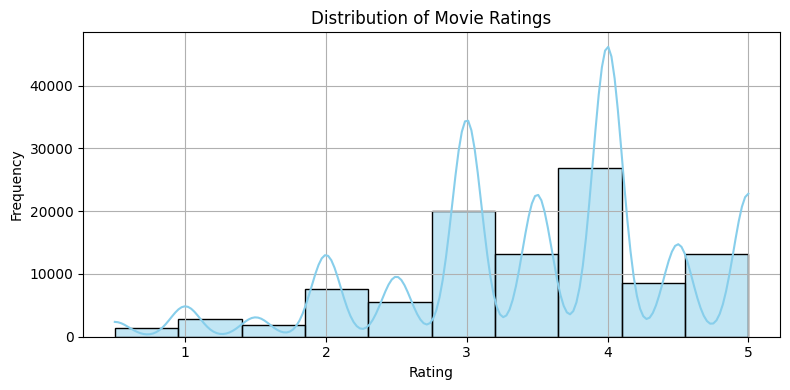

In [31]:
# Draw histogram and smooth curve showing the distribution of ratings
plt.figure(figsize=(8, 4))
sns.histplot(df['rating'], bins=10, kde=True, color='skyblue')  # KDE shows smooth distribution
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Identify which movies were rated the most 
most_rated = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

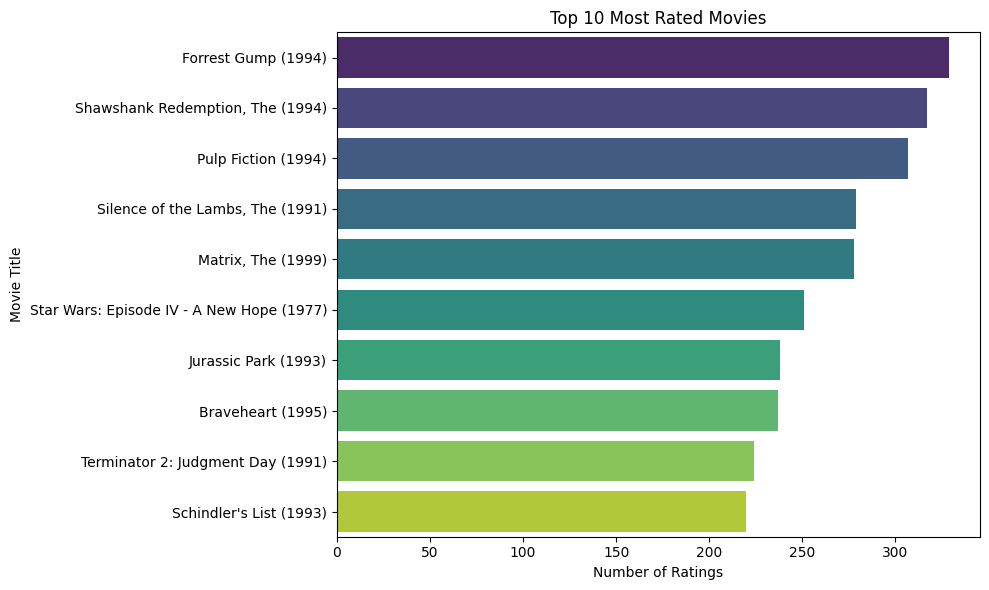

In [33]:
# Show bar plot of top 10 most rated movies
plt.figure(figsize=(10, 6))
sns.barplot(x=most_rated.values, y=most_rated.index, hue=most_rated.index, palette='viridis', legend=False)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

In [34]:
# Get the average rating for each movie
avg_rating = df.groupby('title')['rating'].mean()

In [35]:
# Filter movies with at least 50 ratings and sort by average rating
avg_rating_sorted = avg_rating[df['title'].value_counts() >= 50].sort_values(ascending=False).head(10)

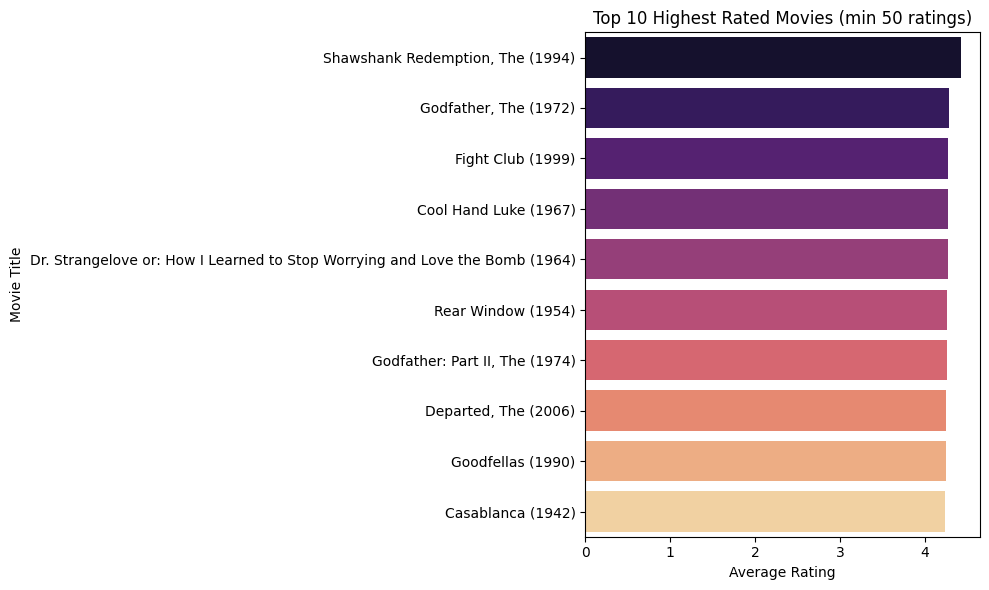

In [36]:
# Show bar plot of top 10 highest rated movies 
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_sorted.values,y=avg_rating_sorted.index,hue=avg_rating_sorted.index,palette='magma',legend=False)
plt.title('Top 10 Highest Rated Movies (min 50 ratings)')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

In [37]:
# Count how many ratings each user gave
user_activity = df['userId'].value_counts()

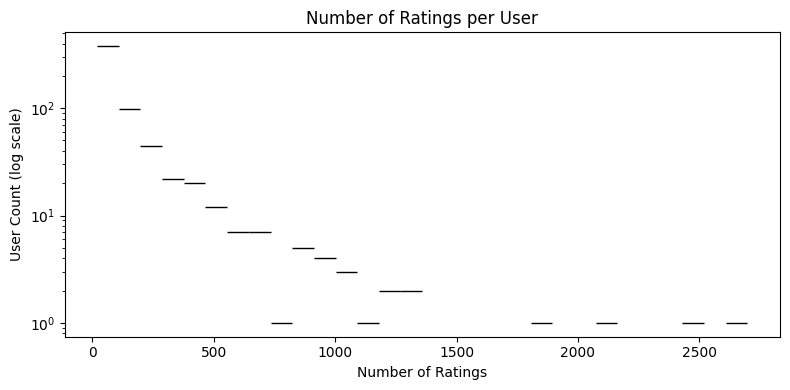

In [38]:
# Plots a histogram of the number of ratings each user has given
plt.figure(figsize=(8, 4))
sns.histplot(user_activity, bins=30, color='salmon', log_scale=(False, True))  # Log scale helps visualize skewed data
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('User Count (log scale)')
plt.tight_layout()
plt.show()

In [39]:
# Split genre strings into lists for each movie
df['genres'] = df['genres'].str.split('|')

In [40]:
# Flatten all genres into one list using a counter
from collections import Counter
genre_counter = Counter([genre for sublist in df['genres'] for genre in sublist])

In [41]:
# Get top genres sorted by frequency
top_genres = pd.Series(genre_counter).sort_values(ascending=False)

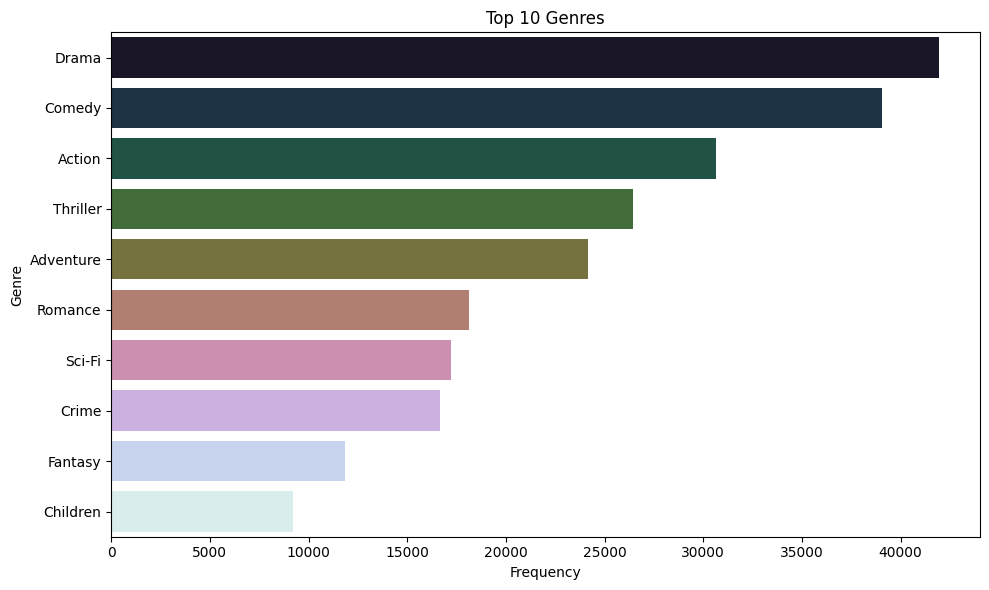

In [42]:
# Show bar plot of top 10 genres
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values[:10],y=top_genres.index[:10],hue=top_genres.index[:10],palette='cubehelix',legend=False)
plt.title('Top 10 Genres')
plt.xlabel('Frequency')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [43]:
# Convert timestamp from Unix to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

In [44]:
# Extract year from timestamp
df['year'] = df['timestamp'].dt.year

In [45]:
# Calculate average rating per year
ratings_by_year = df.groupby('year')['rating'].mean()

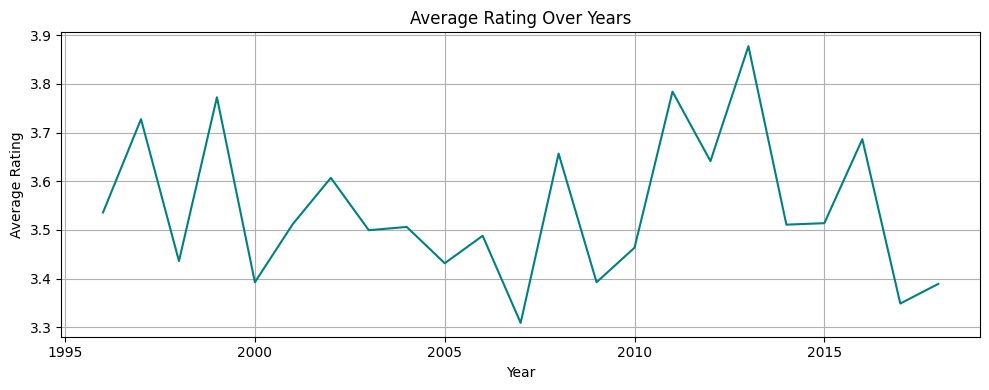

In [46]:
# Show line plot of average rating trends over years
plt.figure(figsize=(10, 4))
sns.lineplot(x=ratings_by_year.index, y=ratings_by_year.values, color='teal')
plt.title('Average Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()